## 데이터 품질 확인

01_data_check에서 만든 Batch1 셀 단위 CSV를 확인합니다. 이 EDA는 구조 확인 다음, 특성 생성 이전 단계입니다.

In [17]:
# 01에서 추출한 Batch1 셀 단위 CSV를 불러옵니다. 현재 EDA의 입력은 이 46개 셀입니다.
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("../data/processed/batch1_cells.csv")

df = pd.read_csv(DATA_PATH)

# 값과 컬럼 구성을 먼저 보고, 행 수·자료형·결측치·중복을 확인해 분석 가능한 상태인지 점검합니다.
print("===== HEAD =====")
display(df.head())

print("\n===== SHAPE =====")
print(df.shape)

print("\n===== INFO =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATED ROWS =====")
print(df.duplicated().sum())

===== HEAD =====


,cell_id,channel,policy,cycle_life
0,1,47,3.6C(80%)-3.6C,1190
1,2,48,3.6C(80%)-3.6C,1179
2,3,49,3.6C(80%)-3.6C,1177
3,4,50,4C(80%)-4C,1226
4,5,51,4C(80%)-4C,1227



===== SHAPE =====
(46, 4)

===== INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   cell_id     46 non-null     int64
 1   channel     46 non-null     int64
 2   policy      46 non-null     str  
 3   cycle_life  46 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.6 KB

===== MISSING VALUES =====
cell_id       0
channel       0
policy        0
cycle_life    0
dtype: int64

===== DUPLICATED ROWS =====
0


## 기본 분포 분석

수명 분포와 정책별 표본 수·수명 차이를 살펴봅니다. 정책당 셀 수가 적으므로 개별 관측값도 함께 확인합니다.

In [18]:
# cycle_life 등의 범위를 파악하고 정책별 표본 수를 확인해 이후 비교의 해석 범위를 정합니다.
print("===== DESCRIPTIVE STATISTICS =====")
display(df.describe())

# 정책별 셀 수가 적으면 뒤의 평균·중앙값을 강한 결론으로 해석하기 어렵습니다.
print("\n===== POLICY COUNTS =====")
policy_counts = df["policy"].value_counts()
display(policy_counts)

===== DESCRIPTIVE STATISTICS =====


,cell_id,channel,cycle_life
count,46.000000,46.000000,46.000000
mean,23.500000,69.500000,844.717391
std,13.422618,13.422618,184.629198
min,1.000000,47.000000,534.000000
25%,12.250000,58.250000,703.250000
50%,23.500000,69.500000,858.500000
75%,34.750000,80.750000,914.250000
max,46.000000,92.000000,1227.000000



===== POLICY COUNTS =====


policy
3.6C(80%)-3.6C    3
4C(80%)-4C        2
4.8C(80%)-4.8C    2
5.4C(40%)-3.6C    2
5.4C(50%)-3C      2
5.4C(50%)-3.6C    2
5.4C(60%)-3C      2
5.4C(60%)-3.6C    2
5.4C(70%)-3C      2
5.4C(80%)-5.4C    2
6C(30%)-3.6C      2
6C(40%)-3C        2
6C(40%)-3.6C      2
6C(50%)-3C        2
6C(50%)-3.6C      2
6C(60%)-3C        2
7C(30%)-3.6C      2
7C(40%)-3C        2
7C(40%)-3.6C      2
8C(15%)-3.6C      2
8C(25%)-3.6C      2
8C(35%)-3.6C      2
4.4C(80%)-4.4C    1
Name: count, dtype: int64

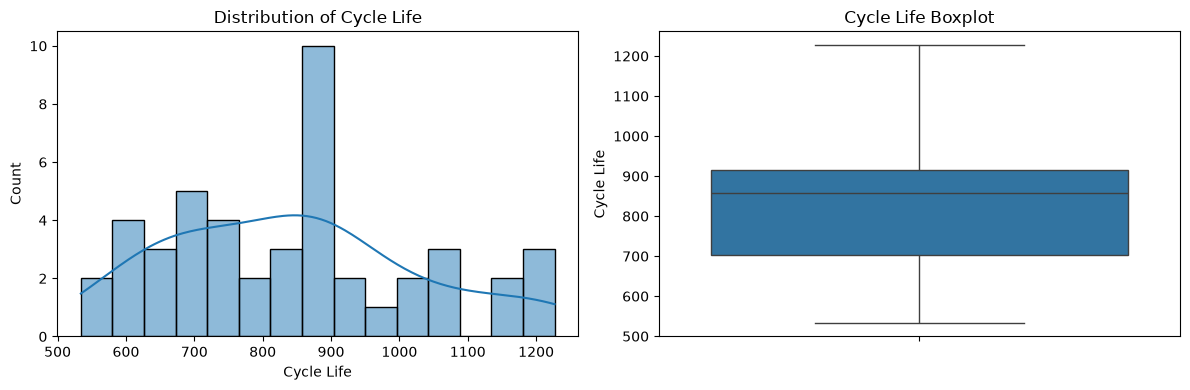

In [19]:
# 전체 수명 분포의 집중 구간, 비대칭성, 극단값 후보를 두 그림으로 살펴봅니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 히스토그램은 빈도와 분포 모양을, 박스플롯은 사분위 범위와 이상치 후보를 보여줍니다.
# 히스토그램
sns.histplot(
    data=df,
    x="cycle_life",
    bins=15,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution of Cycle Life")
axes[0].set_xlabel("Cycle Life")
axes[0].set_ylabel("Count")

# 박스플롯
sns.boxplot(
    data=df,
    y="cycle_life",
    ax=axes[1]
)
axes[1].set_title("Cycle Life Boxplot")
axes[1].set_ylabel("Cycle Life")

plt.tight_layout()
plt.show()

,count,mean,median,min,max
policy,,,,,
4C(80%)-4C,2,1226.5,1226.5,1226,1227
3.6C(80%)-3.6C,3,1182.0,1179.0,1177,1190
4.4C(80%)-4.4C,1,1074.0,1074.0,1074,1074
8C(15%)-3.6C,2,1008.5,1008.5,966,1051
5.4C(40%)-3.6C,2,966.5,966.5,879,1054
6C(30%)-3.6C,2,952.5,952.5,891,1014
6C(40%)-3C,2,935.5,935.5,854,1017
5.4C(50%)-3.6C,2,899.5,899.5,897,902
6C(50%)-3C,2,888.5,888.5,860,917


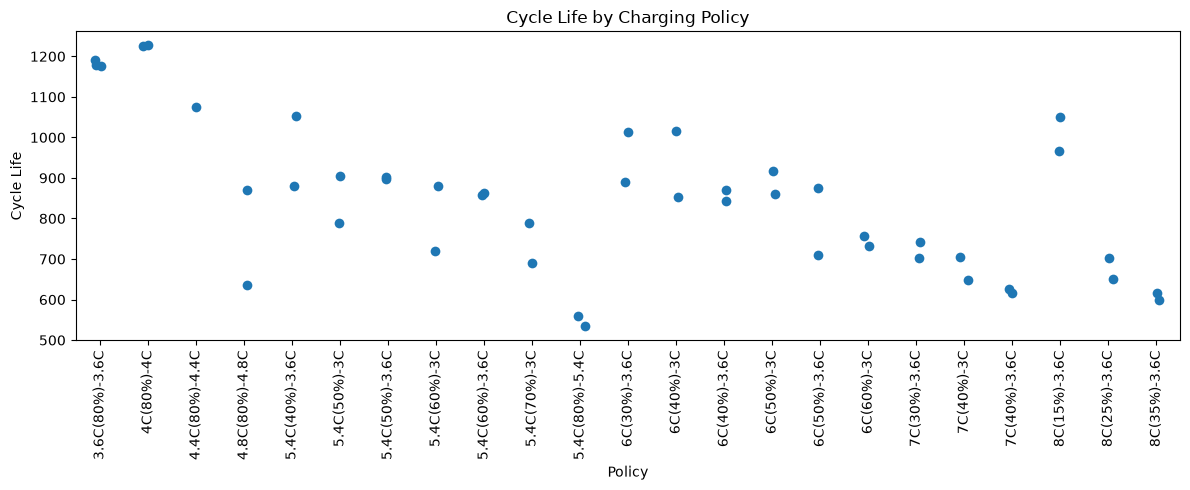

In [20]:
# 정책별 수명 요약과 개별 셀의 산포를 함께 보며 정책 간 차이와 내부 편차를 확인합니다.
policy_stats = (
    df.groupby("policy")["cycle_life"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(policy_stats)

# 표본 수가 적으므로 요약 통계만 보지 않고 strip plot에 각 관측값을 표시합니다.
plt.figure(figsize=(12, 5))

sns.stripplot(
    data=df,
    x="policy",
    y="cycle_life",
    jitter=True,
    size=7
)

plt.xticks(rotation=90)
plt.title("Cycle Life by Charging Policy")
plt.xlabel("Policy")
plt.ylabel("Cycle Life")

plt.tight_layout()
plt.show()

## 충전 정책 분해

정책 문자열에서 First C-rate, Switch SOC, Second C-rate를 추출해 비교 가능한 숫자 변수로 만듭니다.

In [21]:
# 정책 문자열을 세 숫자 변수로 풀어 충전 조건과 수명의 관계를 살펴볼 준비를 합니다.
import re

def parse_policy(policy):
    # 예: 3.6C(80%)-3.6C → 최초 C-rate, 전환 SOC, 이후 C-rate.
    pattern = r"([\d.]+)C\((\d+)%\)-([\d.]+)C"
    match = re.match(pattern, policy)

    if match:
        return pd.Series({
            "first_c_rate": float(match.group(1)),
            "switch_soc": int(match.group(2)),
            "second_c_rate": float(match.group(3))
        })

    # 형식이 맞지 않는 정책은 결측값으로 두어 파싱 실패를 확인할 수 있게 합니다.
    return pd.Series({
        "first_c_rate": None,
        "switch_soc": None,
        "second_c_rate": None
    })

policy_features = df["policy"].apply(parse_policy)

df_policy = pd.concat(
    [df, policy_features],
    axis=1
)

df_policy.head()

,cell_id,channel,policy,cycle_life,first_c_rate,switch_soc,second_c_rate
0,1,47,3.6C(80%)-3.6C,1190,3.6,80.0,3.6
1,2,48,3.6C(80%)-3.6C,1179,3.6,80.0,3.6
2,3,49,3.6C(80%)-3.6C,1177,3.6,80.0,3.6
3,4,50,4C(80%)-4C,1226,4.0,80.0,4.0
4,5,51,4C(80%)-4C,1227,4.0,80.0,4.0


## 정책 변수와 cycle life 관계 분석

각 변수의 단독 관계를 본 뒤 First C-rate와 Switch SOC의 조합을 살펴봅니다. 이 단계의 패턴은 탐색적 관찰입니다.

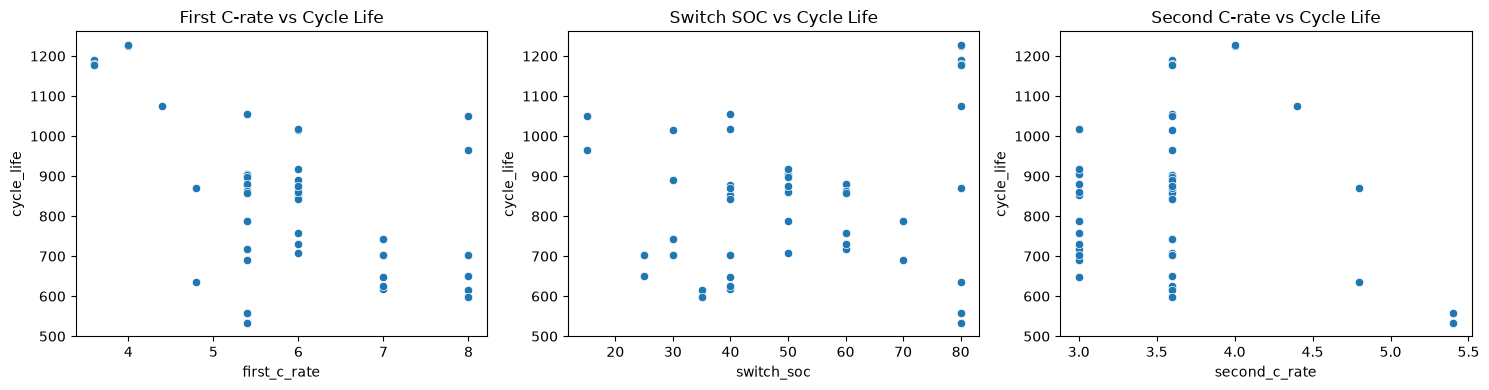

In [22]:
# 세 정책 변수 각각과 cycle_life의 관계를 수치와 산점도로 탐색합니다.
# 상관계수는 선형 경향의 참고값이며, 표본 수와 중복 조건을 함께 고려해야 합니다.
df_policy[
    ["first_c_rate", "switch_soc", "second_c_rate", "cycle_life"]
].corr()

# 각 산점도에서 방향성뿐 아니라 같은 조건에서의 수명 편차도 확인합니다.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(
    data=df_policy,
    x="first_c_rate",
    y="cycle_life",
    ax=axes[0]
)
axes[0].set_title("First C-rate vs Cycle Life")

sns.scatterplot(
    data=df_policy,
    x="switch_soc",
    y="cycle_life",
    ax=axes[1]
)
axes[1].set_title("Switch SOC vs Cycle Life")

sns.scatterplot(
    data=df_policy,
    x="second_c_rate",
    y="cycle_life",
    ax=axes[2]
)
axes[2].set_title("Second C-rate vs Cycle Life")

plt.tight_layout()
plt.show()

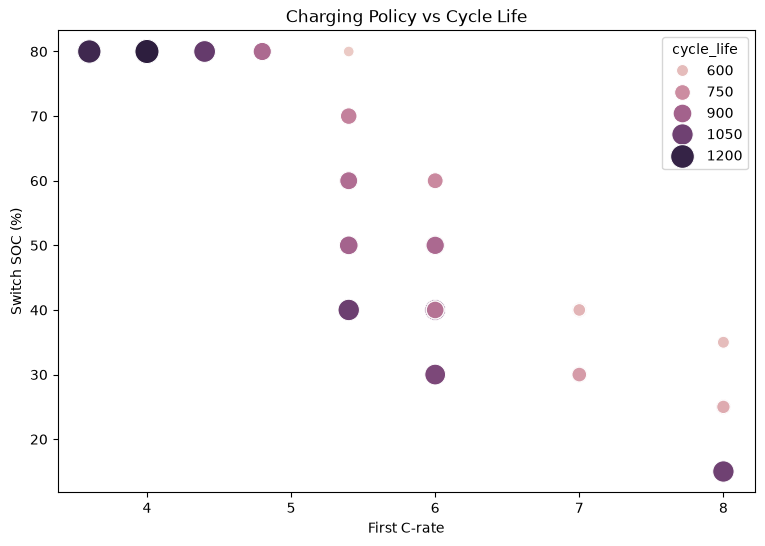

In [23]:
# First C-rate와 Switch SOC의 조합별 수명을 비교해 단일 변수에서 놓친 패턴을 찾습니다.
plt.figure(figsize=(9, 6))

# 점의 색과 크기로 cycle_life를 표시합니다. 같은 좌표의 셀은 겹쳐 보일 수 있습니다.
sns.scatterplot(
    data=df_policy,
    x="first_c_rate",
    y="switch_soc",
    size="cycle_life",
    hue="cycle_life",
    sizes=(50, 300)
)

plt.title("Charging Policy vs Cycle Life")
plt.xlabel("First C-rate")
plt.ylabel("Switch SOC (%)")
plt.show()

## 가설 정리

아래 가설은 Batch1의 셀 단위 메타데이터에 근거합니다. `summary`, `cycles`, `Vdlin`을 사용한 열화 분석과 추가 검증은 아직 진행하지 않았습니다.

전체적으로 First C-rate가 낮고 Switch SOC가 낮은 충전 정책에서 cycle life가 길게 나타나는 경향이 관찰된다. 반대로 높은 C-rate를 비교적 높은 SOC 구간까지 적용한 경우에는 cycle life가 짧아지는 사례가 상대적으로 많이 나타난다. 하지만 동일한 C-rate 조건에서도 cycle life가 크게 달라지는 경우가 있어, C-rate 또는 Switch SOC 하나만으로 배터리 수명을 설명하기는 어렵다. 이에 따라 실제 수명은 First C-rate, Switch SOC, Second C-rate가 함께 구성하는 충전 정책의 상호작용에 의해 영향을 받을 가능성이 있으며, 이후 분석에서는 이 변수들의 조합 효과를 중심으로 추가 검증할 필요가 있다.